## Identifying precip extremes with climatology baseline
### CESM2 large ensemble data 2015-2050

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import numpy as np
import xarray as xr
from matplotlib import rcParams
import pandas as pd
from os import listdir
import matplotlib as mpl
import cftime
import glob
import math
import sys
import nc_time_axis
#import xcdat
import datetime

ERROR 1: PROJ: proj_create_from_database: Cannot find proj.db


In [2]:
rcParams['font.size'] = 20

In [3]:
#define file locations
file_loc = '/div/no-backup/Large_Ensemble_data/CESM2-LENS'

#experiment name (ssp370 or ssp370-126aer)
exp_name = 'BSSP370smbb' #sys.argv[1] #'ssp370-126aer'

#change variable file label name, sets variable to read in
var_filelab = 'PRECT'

#index variable name
var_name = 'PRECT'

sigma_level = 4. #float(sys.argv[2]) #4.
sigma_lab = int(sigma_level)

lower_level = sigma_level -1
lower_sigma_lab = int(lower_level)

#output file location
output_write = '/div/nac/users/zofias/XXN/extreme_loc_tables'
out_plots = '/div/nac/users/zofias/plots/XXN'

In [4]:
# select region by changing region_label
region_label = 'NO' #sys.argv[3] #'EU' # 'SA' 'EA' 'NA' 'EU'

regions = {'SA': [5,35,65,95],
           'EA' : [20,53,95,133],
           'NA' : [25,70,-150,-45],
           'EU' : [35,70,-20,45],
           'NO' : [53,72,0,32]}

#selects lat lon bounds for region
lat_min, lat_max, lon_min, lon_max = regions[region_label]

In [5]:
var_filepath = f"{file_loc}/{exp_name}/{var_filelab}"

#file_years = '20150101-20541231'

#def make_filename(ens, years):
#    filename = f"b.e21.BSSP370smbb.f09_g17.LE2-{ens}.cam.h1.PRECT.{years}.nc"
#    return filename

#r1011001_files = f"{var_filepath}/{make_filename('1011.001',file_years)}"
#r1031002_files = f"{var_filepath}/{make_filename('1031.002',file_years)}"
#r1051003_files = f"{var_filepath}/{make_filename('1051.003',file_years)}"
#r1071004_files = f"{var_filepath}/{make_filename('1071.004',file_years)}"
#r1091005_files = f"{var_filepath}/{make_filename('1091.005',file_years)}"
#r1111006_files = f"{var_filepath}/{make_filename('1111.006',file_years)}"
#r1131007_files = f"{var_filepath}/{make_filename('1131.007',file_years)}"
##r1151008_files = f"{var_filepath}/{make_filename('1151.008',file_years)}"
#r1171009_files = f"{var_filepath}/{make_filename('1171.009',file_years)}"
#r1191010_files = f"{var_filepath}/{make_filename('1191.010',file_years)}"

In [6]:
#define filelist
filelist = sorted(glob.glob(f'{var_filepath}/*h1*.nc'))

# check filename label and adjust if incorrect
# should be e.g. 1011.001
#for file in filelist:
#    filelab = file.split('/')[-1][30:-34]
#    print(filelab)

#experiment labels from filelist
ens_labs = [file.split('/')[-1][30:-34] for file in filelist]

In [7]:
ensemble_array = xr.open_mfdataset(filelist[:5], decode_times=True, combine="nested", concat_dim="member",data_vars=[var_name]).sel(time=slice('2015-01-01','2020-12-31'))

#make member coord labels correct
ensemble_array.coords['member'] = ens_labs[:5]

In [8]:
ensemble_array

<xarray.Dataset>
Dimensions:    (time: 2190, bnds: 2, lat: 192, lon: 288, member: 5)
Coordinates:
  * time       (time) object 2015-01-01 00:00:00 ... 2020-12-31 00:00:00
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * member     (member) <U8 '1011.001' '1031.002' ... '1071.004' '1091.005'
Dimensions without coordinates: bnds
Data variables: (12/14)
    time_bnds  (time, bnds) object dask.array<chunksize=(2190, 2), meta=np.ndarray>
    gw         (lat) float64 dask.array<chunksize=(192,), meta=np.ndarray>
    date       (time) int32 dask.array<chunksize=(2190,), meta=np.ndarray>
    datesec    (time) int32 dask.array<chunksize=(2190,), meta=np.ndarray>
    ndcur      (time) int32 dask.array<chunksize=(2190,), meta=np.ndarray>
    nscur      (time) int32 dask.array<chunksize=(2190,), meta=np.ndarray>
    ...         ...
    n2ovmr     (time) float64 dask.array<chunksize=(2190,), meta=np.ndarray>
    f11vmr     (time) float64 dask.array<chunksize=(2190,), meta=np.ndarray>
    f12vmr     (time) float64 dask.array<chunksize=(2190,), meta=np.ndarray>
    sol_tsi    (time) float64 dask.array<chunksize=(2190,), meta=np.ndarray>
    nsteph     (time) int32 dask.array<chunksize=(2190,), meta=np.ndarray>
    PRECT      (member, time, lat, lon) float32 dask.array<chunksize=(1, 2190, 192, 288), meta=np.ndarray>
Attributes:
    CDI:               Climate Data Interface version 2.1.1 (https://mpimet.m...
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BSSP370smbb.f09_g17.LE2-1011.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.BHISTsmbb.f09_g17.LE2-1011.001.cam.i.2015-01-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    history:           Wed Jun 18 09:36:04 2025: cdo mergetime b.e21.BSSP370s...
    CDO:               Climate Data Operators version 2.1.1 (https://mpimet.m...

In [9]:
#select lats and lons, switch lon to -180 to 180
ensemble_array = ensemble_array.assign_coords(lon=(((ensemble_array.lon + 180) % 360) - 180)).sortby('lon')
ensemble_array = ensemble_array.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

In [10]:
ensemble_array['PRECT'] = ensemble_array['PRECT']*8.64e7
ensemble_array["PRECT"] = ensemble_array.PRECT.assign_attrs(units='mm/day')

In [11]:
print('data read in')

data read in


### Land mask

In [12]:
land_mask_fileloc = '/div/nac/users/zofias/CESM_output/land_mask/Norway_mask_192_288_CESM2-LENS.nc'
land_percent_data = xr.open_dataset(land_mask_fileloc)#.rename({'lon': 'longitude','lat': 'latitude'})

land_percent_data = land_percent_data.assign_coords(lon=(((land_percent_data.lon + 180) % 360) - 180)).sortby('lon')
#land_percent_regional = land_percent_data.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))

In [13]:
#create boolean array of land mask (True = land)
land_mask = land_percent_data.mask

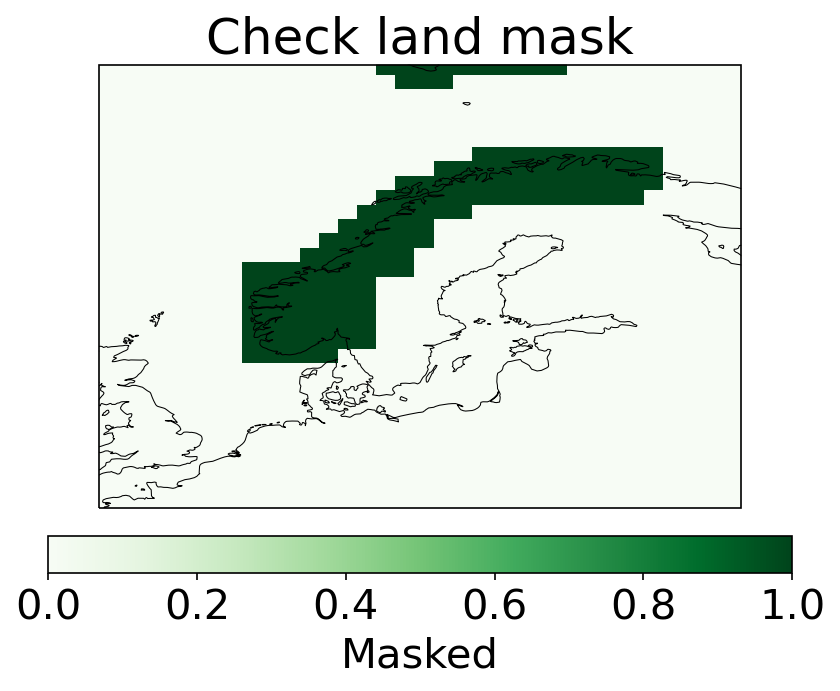

In [14]:
#Check land mask on map plot
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = land_mask.plot(cmap='Greens',
    cbar_kwargs={'label': f'Masked','orientation':'horizontal','pad':0.05},
    xlim=(lon_min-5,lon_max+5),
    ylim=(lat_min-5,lat_max+5),
    )

plt.title(f"Check land mask")
axis.coastlines(linewidth=0.5)  # cartopy function
#axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

In [15]:
#mask array, anything not land has data = nan
ensemble_array_m = ensemble_array.where(land_mask)
print('land mask done')

land mask done


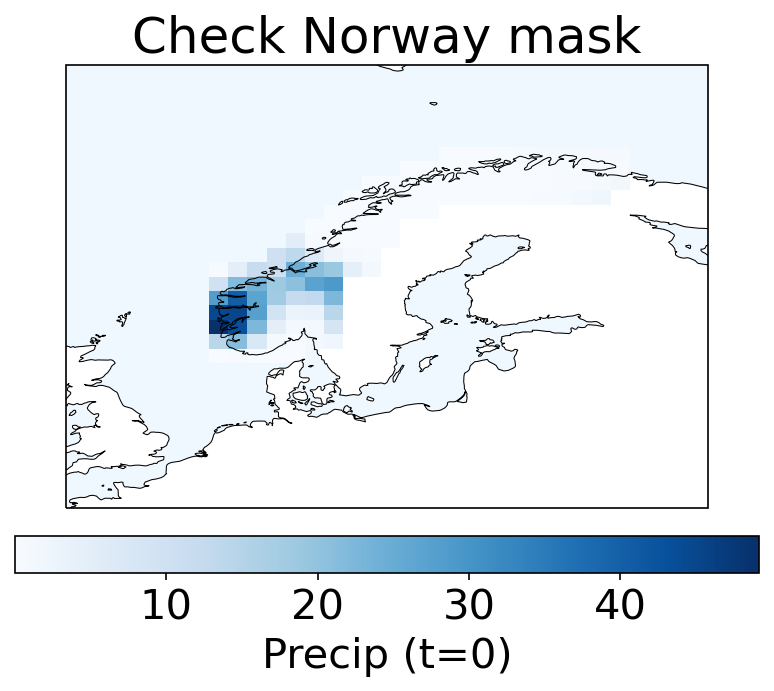

In [16]:
#Check land mask on map plot
fig, axis = plt.subplots(1, 1, dpi=150, subplot_kw=dict(projection=ccrs.PlateCarree()))
fg = ensemble_array_m['PRECT'].isel(time=0).isel(member=0).plot(cmap='Blues',
    cbar_kwargs={'label': f'Precip (t=0)','orientation':'horizontal','pad':0.05},
    xlim=(lon_min-5,lon_max+5),
    ylim=(lat_min-5,lat_max+5),
    )

plt.title(f"Check Norway mask")
axis.coastlines(linewidth=0.5)  # cartopy function
axis.add_feature(cartopy.feature.OCEAN,facecolor=("aliceblue"))

### Calculate 5day sum and climatology

In [17]:
#calculate 5 day sum
ensemble_array_m['rx5day'] = ensemble_array_m[var_name].rolling(time=5,min_periods=5,center=True).sum(skipna=True)#.mean(dim='member',skipna=True)

In [18]:
ds_climo = ensemble_array_m['rx5day'].groupby('time.month').mean('time').mean(dim='member',skipna=True).to_dataset()
ds_anoms = (ensemble_array_m['rx5day'].groupby('time.month') - ds_climo)

Text(0.5, 1.0, 'Climatology')

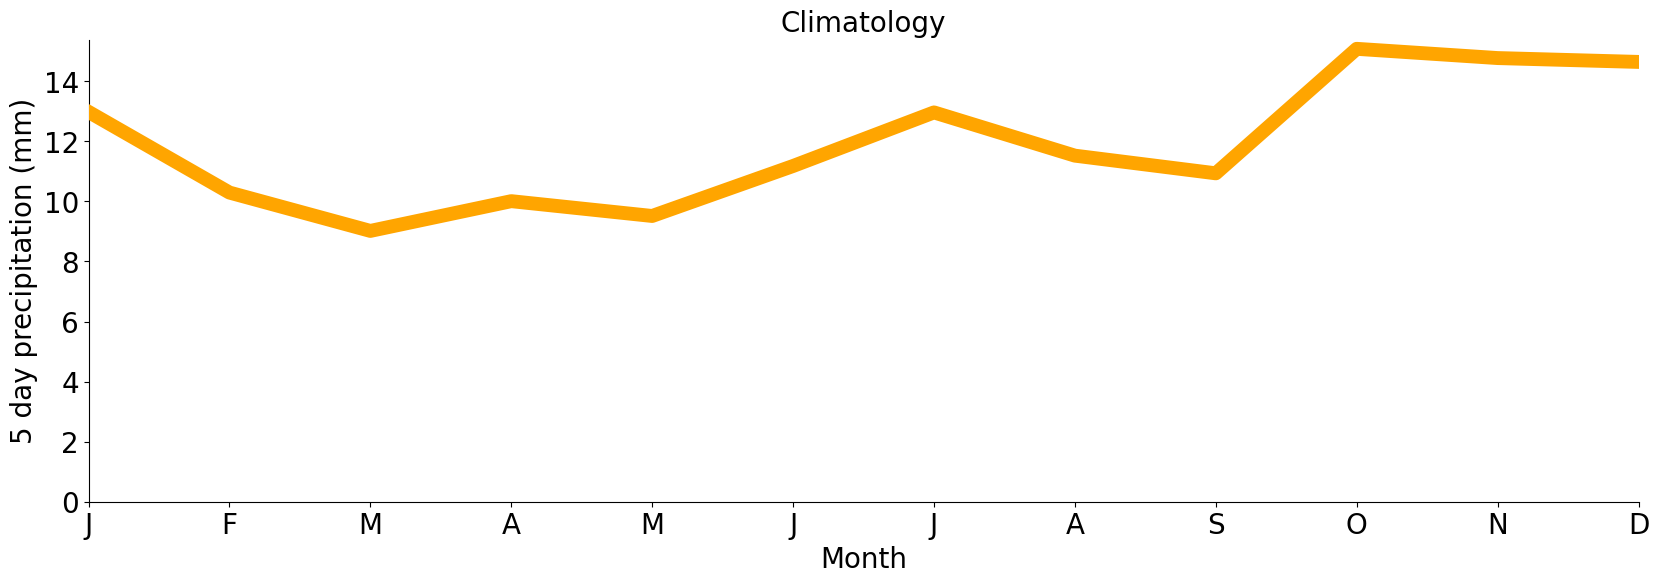

In [19]:
plt.figure(figsize=(20,6))   # width, height

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True


ds_climo['rx5day'].sel(lat=59.91273,lon=10.74609,method='nearest').plot(label='Monthly mean',c='orange',linewidth=10,zorder=10)

#plt.legend();
plt.ylabel('5 day precipitation (mm)')
plt.xlabel('Month')

plt.xlim(1,12)
plt.ylim(0, None)

plt.xticks(np.arange(1,13),labels=["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title(label="Climatology", fontsize=20)

Text(0.5, 1.0, 'Anomaly wrt climatology')

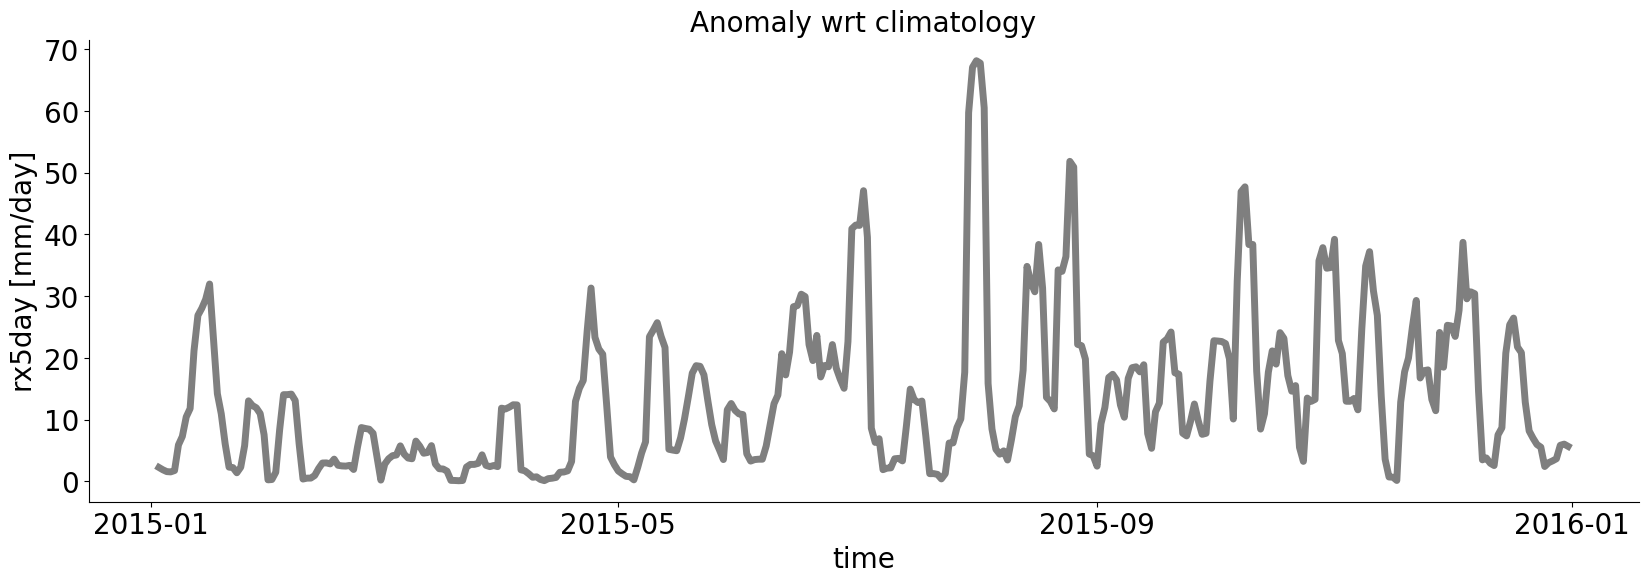

In [20]:
plt.figure(figsize=(20,6))   # width, height
for index,en_mem in enumerate(ens_labs[:1]):
    ensemble_array_m['rx5day'].sel(member=en_mem).sel(lat=59.91273,lon=10.74609,method='nearest').sel(time=slice('2015-01-01','2015-12-31')).plot(label = ens_labs[:5][index],linewidth = 5,c='black',alpha=0.5)

#plt.legend();
plt.title(label="Anomaly wrt climatology", fontsize=20)

### Calculate sigma levels

In [21]:
#calculate standard deviation
#ds_climo['std_daily'] = ensemble_array_m['rx5day'].groupby('time.dayofyear').mean('time').std('member')
ds_climo['std_monthly'] = ensemble_array_m['rx5day'].groupby('time.month').std(('member','time'))

#ds_anoms['std'] = ds_anoms['rx5day'].std(dim=('member','time'))
ds_climo['sigma_level'] = sigma_level * ds_climo['std_monthly']

In [22]:
#make datetime list for monthly whole time period
monthly_climo_datetimes = xr.date_range(start="2015-01-01",end="2020-12-01",freq='MS',use_cftime=True)

In [23]:
#make std monthly dataset
std_monthly_ds = xr.concat([ds_climo.std_monthly]*6,dim='month').to_dataset()
std_monthly_ds['month'] = monthly_climo_datetimes

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, 'Climatology of standard deviation')

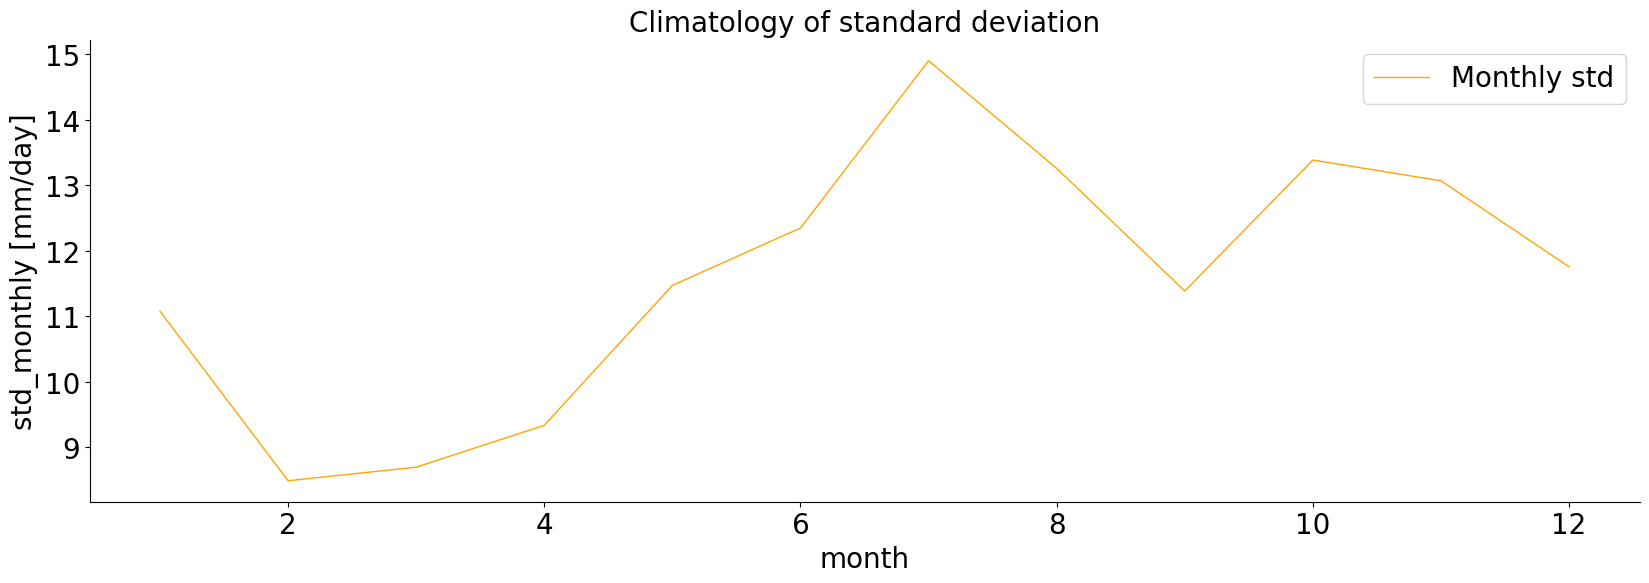

In [24]:
plt.figure(figsize=(20,6))   # width, height
ds_climo['std_monthly'].sel(lat=59.91273,lon=10.74609,method='nearest').plot(label='Monthly std',c='orange',linewidth=1,zorder=10)

plt.legend();
plt.title(label="Climatology of standard deviation", fontsize=20)

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Text(0.5, 1.0, 'Detrended temp + climatology')

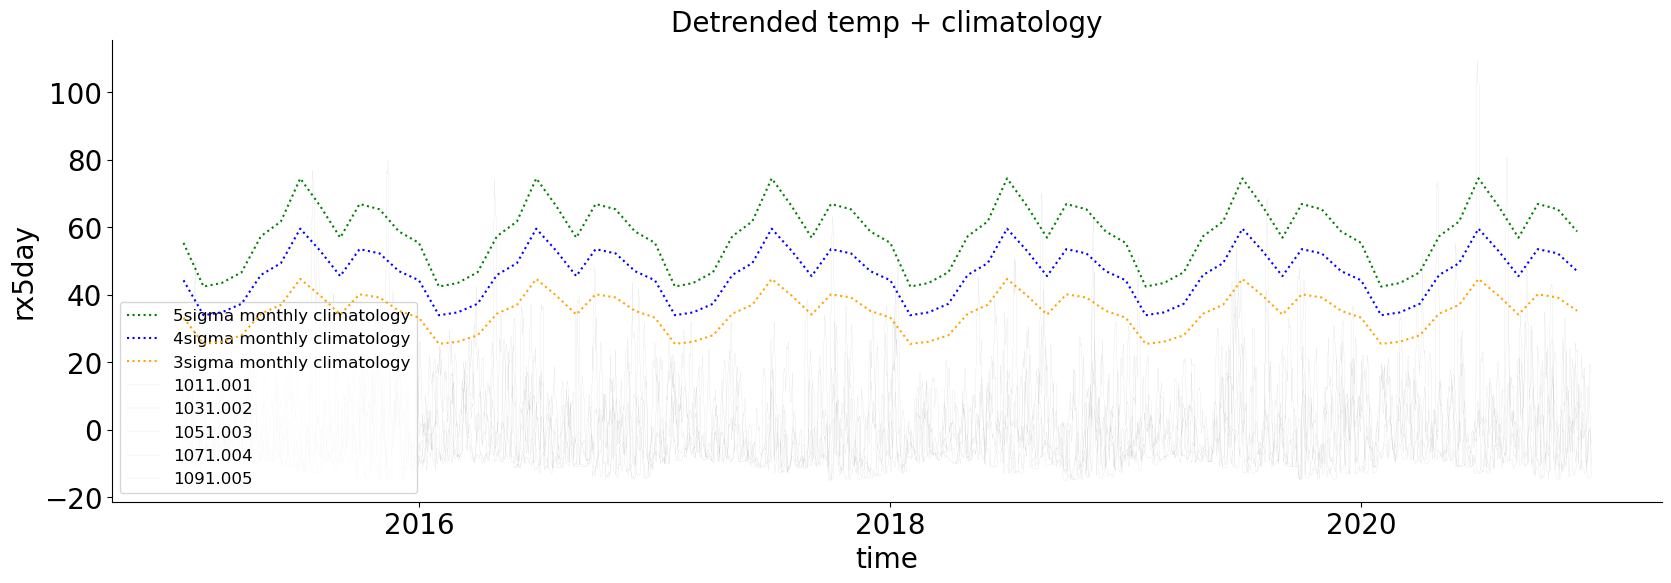

In [25]:
plt.figure(figsize=(20,6))   # width, height

(std_monthly_ds['std_monthly'].sel(lat=59.91273,lon=10.74609,method='nearest')*5).plot(label='5sigma monthly climatology',linestyle = ':',c='green',zorder=10)
(std_monthly_ds['std_monthly'].sel(lat=59.91273,lon=10.74609,method='nearest')*4).plot(label='4sigma monthly climatology',linestyle = ':',c='blue',zorder=10)
(std_monthly_ds['std_monthly'].sel(lat=59.91273,lon=10.74609,method='nearest')*3).plot(label='3sigma monthly climatology',linestyle = ':',c='orange',zorder=10)


#plt.axhline(y=(ds_anoms['std'].sel(lat=59.91273,lon=10.74609,method='nearest')*4),label='4sigma anom',linestyle = ':',c='blue',zorder=9)

for index,en_mem in enumerate(ens_labs[:5]):
    ds_anoms['rx5day'].sel(member=en_mem).sel(lat=59.91273,lon=10.74609,method='nearest').plot(label = ens_labs[:5][index],linewidth = 0.05,c='grey')


#plt.axhline(y=(std_for_plotting*4).sel(lat=59.91273,lon=10.74609,method='nearest'),label='4sigma',linestyle = ':',c='blue')
#plt.axhline(y=(std_for_plotting*5).sel(lat=59.91273,lon=10.74609,method='nearest'),label='5sigma',linestyle = ':',c='pink')
plt.legend(fontsize=12,loc=3)
plt.title(label="Detrended temp + climatology", fontsize=20)

/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/div/qbo/users/py3Env/venv_basic/lib/python3.8/site-packages/dask/array/numpy_compat.py:40: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


Text(0.5, 0, '')

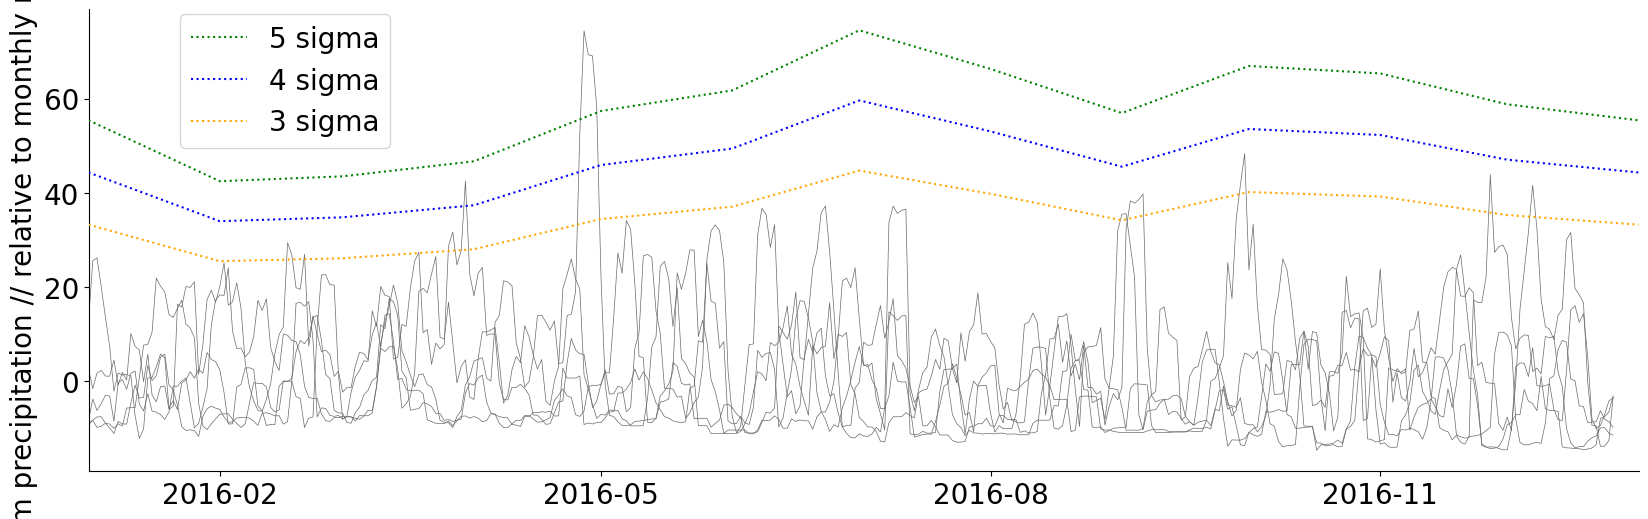

In [26]:
plt.figure(figsize=(20,6))   # width, height

std_monthly_selected = std_monthly_ds['std_monthly'].sel(month=slice('2016-01-01','2017-01-01')).sel(lat=59.91273,lon=10.74609,method='nearest') 

(std_monthly_selected*5).plot(label='5 sigma',linestyle = ':',c='green',zorder=10)
(std_monthly_selected*4).plot(label='4 sigma',linestyle = ':',c='blue',zorder=10)
(std_monthly_selected*3).plot(label='3 sigma',linestyle = ':',c='orange',zorder=10)


#plt.axhline(y=(ds_anoms['std'].sel(lat=59.91273,lon=10.74609,method='nearest')*4),label='4sigma anom',linestyle = ':',c='blue',zorder=9)

for index,en_mem in enumerate(ens_labs[:5]):
    ds_anoms['rx5day'].sel(member=en_mem).sel(time=slice('2016-01-01','2016-12-31')).sel(lat=59.91273,lon=10.74609,method='nearest').plot(linewidth = 0.5,c='dimgrey')


#plt.axhline(y=(std_for_plotting*4).sel(lat=59.91273,lon=10.74609,method='nearest'),label='4sigma',linestyle = ':',c='blue')
#plt.axhline(y=(std_for_plotting*5).sel(lat=59.91273,lon=10.74609,method='nearest'),label='5sigma',linestyle = ':',c='pink')
plt.xlim(std_monthly_selected.indexes['month'][0], std_monthly_selected.indexes['month'][-1])
plt.legend(fontsize=20,bbox_to_anchor=(0.05, 0.67))
plt.title(label="", fontsize=20)
plt.ylabel(f'5 day sum precipitation // relative to monthly mean (mm)')
plt.xlabel('')